Author: Catherine Gatt

Date: 24/02/2026

Content: 
Violin plot by caste Figure 3C

In [1]:
print('hello')
import pandas as pd
import scanpy as sc
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.pyplot import rc_context
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scanpy as sc
from matplotlib import rc_context
from math import ceil
import scanpy as sc
import pandas as pd


h5ad_file = "/home/catherine/phd/projects/termites/data/znev/combined_no_norm_clustered.h5ad"
adata = sc.read_h5ad(h5ad_file)


hello


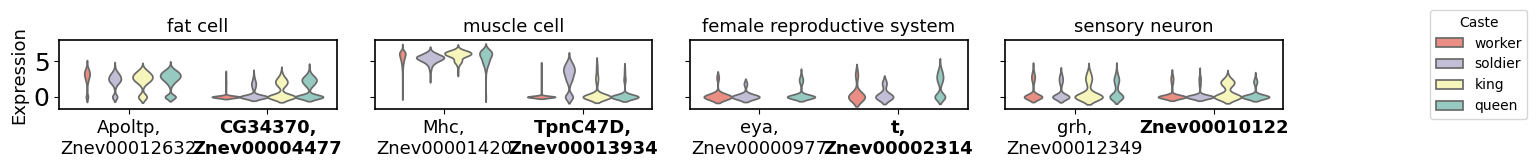

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

def plot_violin_celltype_specific_genes(
    gene_dict,
    adata,
    cell_type_column='paper_cell_type_annotation'
):
    """
    gene_dict: dict mapping cell_type -> list of gene IDs (Znev IDs)
    Label rule:
      - If an ortholog symbol exists in adata.var['dmel_gene_symbol']: "<symbol>,\\n<ZnevID>"
      - If no ortholog: "<ZnevID>" (just the ID)
    """

    # ✅ Desired caste order
    caste_order = ["worker", "soldier", "king", "queen"]

    # Caste color palette (fixed mapping)
    palette = sns.color_palette("Set3", n_colors=4)
    castes = ["queen", "king", "soldier", "worker"]
    palette_dict = dict(zip(castes, palette))

    cell_types = list(gene_dict.keys())
    n_celltypes = len(cell_types)

    fig, axes = plt.subplots(1, n_celltypes, figsize=(14, 1.7), sharey=True)
    if n_celltypes == 1:
        axes = [axes]

    bold_index = 1  # bold the SECOND gene (0-based index)

    for i, cell_type in enumerate(cell_types):
        ax = axes[i]

        # subset to this cell type
        adata_sub = adata[adata.obs[cell_type_column] == cell_type].copy()

        # keep only genes present in adata
        gene_ids_all = gene_dict[cell_type]
        present_ids = [g for g in gene_ids_all if g in adata.var_names]
        if not present_ids:
            ax.set_title(cell_type + " (no genes found)", fontsize=13)
            ax.axis("off")
            continue

        # Build display labels
        display_labels = []
        has_symbol_col = 'dmel_gene_symbol' in adata.var.columns
        for g in present_ids:
            sym = adata.var.at[g, 'dmel_gene_symbol'] if has_symbol_col else None
            if pd.notna(sym) and str(sym).strip():
                display_labels.append(f"{str(sym).strip()},\n{g}")
            else:
                display_labels.append(g)

        # Expression matrix for selected genes
        X = adata_sub[:, present_ids].X
        if not isinstance(X, np.ndarray):
            X = X.toarray()
        expr_df = pd.DataFrame(X, columns=display_labels, index=adata_sub.obs_names)

        # Long form
        expr_df['caste'] = adata_sub.obs['caste'].values
        expr_long = expr_df.melt(id_vars='caste', var_name='gene', value_name='expression')

        # ✅ Violin plot with caste order
        sns.violinplot(
            data=expr_long,
            x='gene', y='expression',
            hue='caste',
            hue_order=caste_order,     # 🔥 controls the order
            order=display_labels,
            split=False,
            inner=None,
            palette=palette_dict,
            ax=ax,
        )

        # Thicken subplot outline
        for spine in ax.spines.values():
            spine.set_linewidth(1.2)

        ax.set_title(cell_type, fontsize=13)
        ax.set_ylabel('' if i > 0 else 'Expression', fontsize=13)
        ax.set_xlabel('')
        ax.tick_params(axis='x', labelrotation=0, labelsize=13)
        ax.tick_params(axis='y', labelrotation=0, labelsize=18)

        # Remove per-axis legend
        leg = ax.get_legend()
        if leg is not None:
            leg.remove()

        # Bold the second gene x tick label
        if len(display_labels) > bold_index:
            target_label = display_labels[bold_index]
            for tick in ax.get_xticklabels():
                if tick.get_text() == target_label:
                    tick.set_fontweight('bold')
                    break

    # Shared legend (will respect hue_order)
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, title='Caste', bbox_to_anchor=(1.02, 1), loc='upper left')

    plt.tight_layout()
    plt.subplots_adjust(right=0.92)
    plt.show()


# Example usage
gene_dict = {
    'fat cell': ['Znev00012632', 'Znev00004477'],
    'muscle cell': ['Znev00001420', 'Znev00013934'],
    'female reproductive system': ['Znev00000977', 'Znev00002314'],
    'sensory neuron': ['Znev00012349', 'Znev00010122'],
}

plot_violin_celltype_specific_genes(gene_dict, adata)